## Visualize loss RE, Z, tổng của mỗi client qua các epoch từ fil train.csv

In [8]:
import pathlib
from pathlib import Path
!pip install matplotlib
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/8.7 MB ? eta -:--:--Downloading matplotlib-3.10.8-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 21.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 21.1 MB/s  0:00:00 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/4.9 MB ? eta -:--:--Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 19.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 19.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.6 MB ? eta -:--:--Downloading kiwisolver-1.4.9-cp310-cp310-manylinux_2_1

In [4]:
log_file = "logs/unsw_DualLossAE_5000_0_average_multi1.0_08_01_2026_11_37_16_train.csv"
# typeloss = ["train_re","train_ptl_loss", "train_loss", "val_loss"]
typeloss = ["train_re", "train_loss", "val_loss"]
client_ids = [0,2,6]
output_dir = Path("visualizes/FedPTL")

In [1]:
log_file = "logs/FedHome_log/unsw_FedHome_1000_0_average_multi0.0_24_12_2025_11_13_14_train.csv"
typeloss = ["train_re","train_ce", "train_loss", "val_loss"]
client_ids = [0,2,6]
output_dir = Path("visualizes/FedHome")

NameError: name 'Path' is not defined

In [5]:
# Load CSV and validate requested losses exist
import pandas as pd
df = pd.read_csv(log_file)
df = df.sort_values(["client_id", "epoch"])

missing = [name for name in typeloss if name not in df.columns]
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}")

df_filtered = df[df["client_id"].isin(client_ids)].copy()
display(df_filtered.head())

,Unnamed: 0,epoch,client_id,is_mal,train_re,train_re_loss,train_ptl_loss,train_loss,threshold_re,threshold_z,best_val_loss,best_epoch,is_training,train_latent_z,val_loss
0,0,1,0,False,0.000204,NaN,NaN,0.000204,"(np.float64(4.835316171930797), np.float64(0.2...","(0, 0)",3.421032,1,True,NaN,3.421032
20,20,2,0,False,0.000468,NaN,NaN,0.000468,"(np.float64(2.128918504181193), np.float64(0.1...","(0, 0)",1.506338,2,True,NaN,1.506338
40,40,3,0,False,0.000385,NaN,NaN,0.000385,"(np.float64(2.269158265272628), np.float64(0.8...","(0, 0)",1.506338,2,True,NaN,1.605533
60,60,4,0,False,0.000543,NaN,NaN,0.000543,"(np.float64(1.601808540356248), np.float64(0.5...","(0, 0)",1.133426,4,True,NaN,1.133426
80,80,5,0,False,0.000523,NaN,NaN,0.000523,"(np.float64(1.6451623792523768), np.float64(0....","(0, 0)",1.133426,4,True,NaN,1.164094


In [9]:
# Plot per-client losses and save to /visuallizes
palette = plt.cm.get_cmap("tab10", len(typeloss))

for cid in client_ids:
    client_df = df_filtered[df_filtered["client_id"] == cid]
    if client_df.empty:
        print(f"Skip client {cid}: no data found in CSV.")
        continue
    
    for idx, loss_name in enumerate(typeloss):
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(client_df["epoch"], client_df[loss_name], label=loss_name, color=palette(idx))
        ax.set_title(f"Client {cid} losses")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        output_dir.mkdir(parents=True, exist_ok=True)
        save_path = output_dir / f"client_{cid}_{loss_name}.png"
        fig.savefig(save_path, dpi=150)
        plt.close(fig)
        print(f"Saved {save_path}")

/tmp/ipykernel_10738/1820585809.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10", len(typeloss))


Saved visualizes/FedPTL/client_0_train_re.png
Saved visualizes/FedPTL/client_0_train_loss.png
Saved visualizes/FedPTL/client_0_val_loss.png
Saved visualizes/FedPTL/client_2_train_re.png
Saved visualizes/FedPTL/client_2_train_loss.png
Saved visualizes/FedPTL/client_2_val_loss.png
Saved visualizes/FedPTL/client_2_train_re.png
Saved visualizes/FedPTL/client_2_train_loss.png
Saved visualizes/FedPTL/client_2_val_loss.png
Saved visualizes/FedPTL/client_6_train_re.png
Saved visualizes/FedPTL/client_6_train_loss.png
Saved visualizes/FedPTL/client_6_val_loss.png
Saved visualizes/FedPTL/client_6_train_re.png
Saved visualizes/FedPTL/client_6_train_loss.png
Saved visualizes/FedPTL/client_6_val_loss.png


## Visuallize Re_loss của lớp bình thường và lớp bất thườn khi train của các client qua từng epoch train cho kịch bản unseen

In [1]:
!pip install loguru

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Visualize per-epoch reconstruction loss (benign vs attack) for one client using saved checkpoints
from pathlib import Path
import re
import torch
import numpy as np
import matplotlib.pyplot as plt
from loguru import logger
from function.arguments import Arguments
from function.utils import load_test_data_loader
from core.data_processing import client_data_process
from core.client_factory import create_clients
from function.utils.visualize_util import collect_re_and_labels_from_client
from agents.clients import get_client_class

In [31]:
# ---- Config (chỉnh lại cho phù hợp) ----
dataset = "unsw"
model_type = "DualLossAE"
num_clients = 20
target_client = 19
dimension = 196
train_batch_size = 128
val_batch_size = 1
test_batch_size = 1
model_dir = Path(f"saved_models/{model_type}/{num_clients}/average/{dataset}")
epoch_limit = 2000  # đặt số max epoch nếu muốn cắt bớt, hoặc None
device = "cpu"  # đổi sang cuda nếu cần và có GPU

In [32]:
# ---- Chuẩn bị args & client/test loader ----
config = {
    "dataset": dataset,
    "train_batch_size": train_batch_size,
    "val_batch_size": val_batch_size,
    "test_batch_size": test_batch_size,
    "mal_batch_size": val_batch_size,
    "dimension": dimension,
    "epochs": 1,
    "model_type": model_type,
    "noise_type": "label_flipping",
    "num_of_poisoned_workers": 0,
    "poisoned_sample_ratio": 1.0,
    "learning_rate": 0.001,
    "noise_std": 0.001,
    "attack_noise_std": 3.0,
    "aggregation_type": "average",
    "coef_shrink_ae": 1.0,
    "threshold_multiplier": 1.0,
    "num_multi_class_clients": 0,
    "by_attack_type": False,
    "experiment_type": "normal",
}
args = Arguments(logger, config)

In [33]:
test_data_loader = load_test_data_loader(logger, args)
test_data_loaders = client_data_process(args, test_data_loader, None, None, args.test_batch_size, poison=False, data_stage="test")

train_loaders = [None] * args.num_workers
val_loaders = [None] * args.num_workers
clients = create_clients(args, train_loaders, val_loaders, test_data_loaders)

client = clients[target_client]

# ---- Liệt kê checkpoint cho client ----
pattern = re.compile(r"epoch_(\d+)_client_%d\.pt" % target_client)
ckpts = []
for p in model_dir.glob("epoch_*_client_*.pt"):
    m = pattern.match(p.name)
    if m:
        epoch_val = int(m.group(1))
        if epoch_limit is None or epoch_val <= epoch_limit:
            ckpts.append((epoch_val, p))

ckpts = sorted(ckpts, key=lambda x: x[0])
if not ckpts:
    raise FileNotFoundError(f"No checkpoints found for client {target_client} in {model_dir}")
else:
    # log ra số checkpoint tìm được: {len(ckpts)} cái
    logger.info(f"Found {len(ckpts)} checkpoints for client {target_client} in {model_dir}")

epochs = []
re_mean_benign = []
re_mean_attack = []

2026-01-21 07:53:30.233 | INFO     | function.utils.data_loader_util:load_data_loader_from_file:202 - Loading data loader from file: data_loaders/unsw/test_data_loader.pickle
2026-01-21 07:53:31.830 | INFO     | __main__:<module>:25 - Found 200 checkpoints for client 19 in saved_models/DualLossAE/20/average/unsw
2026-01-21 07:53:31.830 | INFO     | __main__:<module>:25 - Found 200 checkpoints for client 19 in saved_models/DualLossAE/20/average/unsw


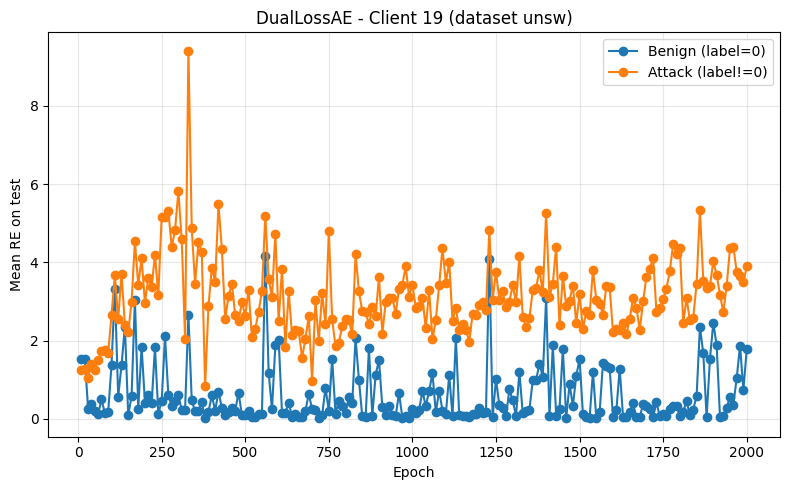

Saved plot -> visualizes/re_loss_0_1/unsw_DualLossAE_client19.png


In [34]:
# ---- Duyệt checkpoint và tính RE ----
for ep, ckpt_path in ckpts:
    state = torch.load(ckpt_path, map_location=device)
    client.update_nn_parameters(state)
    # thu thập reconstruction error trên test
    re_list, labels = collect_re_and_labels_from_client(client)
    labels = np.array(labels)
    re_arr = np.array(re_list, dtype=float)
    if re_arr.size == 0:
        continue
    benign_mask = labels == 0
    attack_mask = labels != 0
    benign_mean = float(re_arr[benign_mask].mean()) if benign_mask.any() else np.nan
    attack_mean = float(re_arr[attack_mask].mean()) if attack_mask.any() else np.nan

    epochs.append(ep)
    re_mean_benign.append(benign_mean)
    re_mean_attack.append(attack_mean)

# ---- Vẽ ----
plt.figure(figsize=(8,5))
plt.plot(epochs, re_mean_benign, label="Benign (label=0)", marker="o")
plt.plot(epochs, re_mean_attack, label="Attack (label!=0)", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Mean RE on test")
plt.title(f"{model_type} - Client {target_client} (dataset {dataset})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
out_dir = Path("visualizes/re_loss_0_1")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f"{dataset}_{model_type}_client{target_client}.png"
plt.savefig(out_path, dpi=150)
plt.show()
print(f"Saved plot -> {out_path}")